# Taller Cálculo de raices

**Nombre:** Joel Velez  **Fecha:** 12/06/2026   **Curso:** GR1CC

# Introducción 
+ Extensión de python: py
+ Extensión de notebook: .ipynb

Símbolo de la terminal
# Bash
```
$ cat
```


Command Prompt | Power Shell
```
> cd
```

Python
```
>>> print("Hola mundo")
````


### Ejercicio 1
Gráfica de precio vs tokens para el modelo GPT 5.5 y diferenciar en los casos de short context y long context.   
Dividir el problema en pasos
+ Necesito tokens, precio
+ tokens: lista de 0 a 1 millón

- Puntos de referencia: 
    Sabemos que USD 30 por cada millón de tokens
    $$\frac{30}{1000000} = 0.000030$$
    \
    Sabemos que USD 45 por cada millón de tokens
    $$\frac{45}{1000000} = 0.000045$$

    \
    Cost base límite:  
    No se puede pasar más de 272000 tokens para ser short context
    $$ 272000 * 0.000030 = 8.16$$


In [4]:
import numpy as np

In [ ]:
# Crea la lista en memoria (0 a 1,000,000)
tokens = list(range(1000001))

In [4]:
limite = 272000
tarifa_short = 30/1_000_000
tarifa_long = 45/ 1_000_000

costo_base_limite = limite * tarifa_short

precios = []
for num in tokens:
    if num <= 272000:
        precios.append(num * tarifa_short)
    else:
        precios.append(costo_base_limite + (num - limite) * tarifa_long)

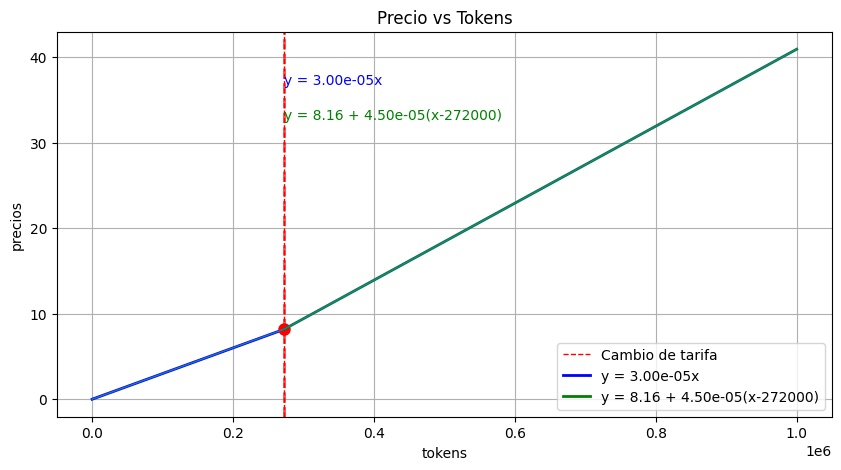

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.axvline(x=limite, color='red', linestyle='--', linewidth=1, label='Cambio de tarifa')
plt.text(limite, max(precios)*0.9, f'y = {tarifa_short:.2e}x', fontsize=10, color='blue')
plt.text(limite, max(precios)*0.8, f'y = {costo_base_limite:.2f} + {tarifa_long:.2e}(x-{limite})', fontsize=10, color='green')
plt.axvline(x=limite, color='red', linestyle='--', linewidth=2, alpha=0.7)
plt.plot(tokens[:limite+1], precios[:limite+1], linewidth=2, color='blue', label=f'y = {tarifa_short:.2e}x')
plt.plot([limite], [costo_base_limite], 'ro', markersize=8)
plt.plot(tokens[limite:], precios[limite:], linewidth=2, color='green', label=f'y = {costo_base_limite:.2f} + {tarifa_long:.2e}(x-{limite})')
plt.legend()
plt.plot(tokens, precios, linewidth=1)
plt.xlabel('tokens')
plt.ylabel('precios')
plt.title('Precio vs Tokens')
plt.grid(True)
plt.show()

### Ejercicio 2
Encontrar todas las raíces de la ecuación $f(x) = \frac{1}{4}(x^3 + 3x^2 - 6x - 8)$
usando el método de la bisección.  Grafique. Modifique el número de iteraciones a 5. Pruebe los siguientes rangos de búsqueda ([-5 3], [-4.7 2.5], [-4.5 2.7], [-3 -2]). 
